### Demographic Features (covariate)

- `user_ID`
- `1st_amyloid_status` (target. postive vs. negative)
- `1st_cognitive_status` (covariate)
- `APOE` // 가감해서 비교
- `sex`
- `education_year`
  - `education_category` // 불필요
  - `졸업여부` // 불필요
- `AGE`

### Used in composite_scores

1. `visual_forward_raw_score`
2. `visual_backward_raw_score`
3. `cowat_fruits_raw_score`
4. `cowat_di_raw_score`
5. `naming_raw_score`
6. `block_design_raw_score`
7. `time_orientation_total_raw_score`
8. `immediate_free_recall_trial_1_raw_score`
9. `immediate_free_recall_trial_2_raw_score`
10. `immediate_free_recall_trial_3_raw_score`
11. `delayed_free_recall_raw_score`
12. `word_recognition_true_positive_raw_score`
13. `word_recognition_true_negative_raw_score`
14. `place_recognition_raw_score`
15. `trailmaking_part_a_time_raw_score`
16. `trailmaking_part_a_error_raw_score`
17. `trailmaking_part_b_time_raw_score`
18. `trailmaking_part_b_error_raw_score`


## Demographic Features and Experiments Plan (.py 등으로 모듈 만들어두기.)

> target: `1st_amyloid_status` diagnosis (postive vs. negative)

### Group 1: `1st_cognitive_status` == All (covariate)

| Model | Covariate (demo features) | composite scores | # of features |
| :---: | :-----------------------: | :--------------: | :-----------: |
| M1 (baseline) | &nbsp; | O | 18 |
| M2 | `1st_cognitive_status` | O | 18 + 2 = 20 |
| M3 | `1st_cognitive_status` + `sex` | O | 18 + 3 = 21 |
| M4 | `1st_cognitive_status` + `sex` + `AGE` | O | 18 + 4 = 22 |
| M5 | `1st_cognitive_status` + `sex` + `AGE` + `education_year` | O | 18 + 5 = 23 |
| M6 | `1st_cognitive_status` + `sex` + `AGE` + `education_year` + `APOE` | O | 18 + 10 = 28 |

### Group 2: `1st_cognitive_status` == SCD

| Model | Covariate (demo features) | composite scores | # of features |
| :---: | :-----------------------: | :--------------: | :-----------: |
| M1_SCD (baseline) | &nbsp; | O | 18 |
| M2_SCD | `sex` | O | 18 + 1 = 19 |
| M3_SCD | `sex` + `AGE` | O | 18 + 2 = 20 |
| M4_SCD | `sex` + `AGE` + `education_year` | O | 18 + 3 = 21 |
| M5_SCD | `sex` + `AGE` + `education_year` + `APOE` | O | 18 + 8 = 26 |

### Group 3: `1st_cognitive_status` == MCI (important)

| Model | Covariate (demo features) | composite scores | # of features |
| :---: | :-----------------------: | :--------------: | :-----------: |
| M1_MCI (baseline) | &nbsp; | O | 18 |
| M2_MCI | `sex` | O | 18 + 1 = 19 |
| M3_MCI | `sex` + `AGE` | O | 18 + 2= 20 |
| M4_MCI | `sex` + `AGE` + `education_year` | O | 18 + 3 = 21 |
| M5_MCI | `sex` + `AGE` + `education_year` + `APOE` | O | 18 + 8 = 26 |

### Group 4: `1st_cognitive_status` == Dementia

| Model | Covariate (demo features) | composite scores | # of features |
| :---: | :-----------------------: | :--------------: | :-----------: |
| M1_Dementia (baseline) | &nbsp; | O | 18 |
| M2_Dementia | `sex` | O | 18 + 1 = 19 |
| M3_Dementia | `sex` + `AGE` | O | 18 + 2 = 20 |
| M4_Dementia | `sex` + `AGE` + `education_year` | O | 18 + 3 = 21 |
| M5_Dementia | `sex` + `AGE` + `education_year` + `APOE` | O | 18 + 8 = 26 |

***

# Data Merge

In [1]:
import sys
sys.path.append("..")  # 상위 폴더를 파이썬이 찾는 경로에 추가

from raw_to_merge import preprocess_and_merge

In [2]:
raw_path = "../../Data/Raw/scstBiomark_vaccine_naive_889_no_biomarker_filter_deidentified.xlsx"
save_path = "../../Data/Preprocessed/scstBiomark_vaccine_naive_889_no_biomarker_filter_deidentified_merged.xlsx"

In [3]:
# preprocess_and_merge(raw_path = raw_path, save_path = save_path)

## Data Load

In [4]:
import numpy as np
import pandas as pd
path = save_path
df_composite = pd.read_excel(path, sheet_name='composite_scores')

In [5]:
df_composite

,user_ID,1st_amyloid_status,1st_cognitive_status,APOE,population,sex,education_category,졸업여부,education_year,AGE,...,trailmaking_part_a_time_z_score,trailmaking_part_a_error_z_score,trailmaking_part_b_time_z_score,trailmaking_part_b_error_z_score,cst_attention_z_score,cst_language_z_score,cst_visuospatial_z_score,cst_memory_z_score,cst_executive_z_score,cst_total_z_score
0,183,음성,SCD,E3/E4,기존 455명 (과정지표 있음),여성,고등학교,졸업,12,69,...,-0.38,0.37,0.33,0.46,0.47,0.73,-0.20,-0.91,-0.02,0.04
1,248,음성,MCI,E3/E4,기존 455명 (과정지표 있음),여성,대학원(석사),졸업,18,81,...,-0.45,0.27,-0.88,-0.48,-0.18,-2.02,-1.74,-2.14,-0.79,-2.09
2,265,양성,Dementia,E3/E4,기존 455명 (과정지표 있음),여성,대학교,졸업,16,87,...,-0.22,0.49,-1.19,-1.33,0.52,0.16,-1.26,-3.44,-0.84,-1.42
3,283,양성,MCI,E3/E4,기존 455명 (과정지표 있음),여성,대학교,졸업,16,73,...,-0.56,-1.32,0.89,0.10,1.62,1.93,1.07,1.39,0.22,1.93
4,426,음성,SCD,E3/E3,기존 455명 (과정지표 있음),여성,초등학교,중퇴,4,84,...,0.52,-0.47,0.06,-0.95,1.38,-0.04,-0.33,2.06,0.33,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884,8988,음성,Dementia,E2/E3,과정지표 없음(신규 포함),여성,대학교,졸업,16,77,...,0.97,0.32,-2.22,0.21,-0.02,-2.63,-1.71,-4.25,-0.78,-2.84
885,8989,음성,Dementia,E3/E3,과정지표 없음(신규 포함),남성,대학원(석사),졸업,18,78,...,-0.54,0.23,-0.82,-0.04,-0.67,-0.76,-2.16,-3.75,-0.81,-2.45
886,9079,양성,Dementia,E3/E4,과정지표 없음(신규 포함),여성,초등학교,졸업,6,73,...,-0.68,0.77,-1.42,0.44,0.96,-1.59,0.60,-3.95,-1.25,-1.51
887,9195,양성,Dementia,E3/E4,과정지표 없음(신규 포함),여성,고등학교,졸업,12,79,...,-0.61,0.56,-1.31,0.24,-0.99,-0.38,-0.22,-2.30,-1.14,-1.47


- 분포 체크

In [ ]:
# pd.crosstab(
#     df_composite['1st_cognitive_status'].astype(pd.CategoricalDtype(['SCD', 'MCI', 'Dementia'], ordered=True)),
#     df_composite['1st_amyloid_status'],
#     margins=True, margins_name='Total'
# )

1st_amyloid_status,양성,음성,Total
1st_cognitive_status,,,
SCD,35,179,214
MCI,142,261,403
Dementia,185,87,272
Total,362,527,889


### DROP columns

In [7]:
df_composite = df_composite.drop(columns=["population", "education_category", "졸업여부"], errors="ignore")

### Fill NA

In [8]:
# df 전체 컬럼에서 NaN 개수 확인
na_counts = df_composite.isna().sum()
print(na_counts[na_counts > 0])

place_recognition_z_score    1
cst_memory_z_score           1
cst_total_z_score            1
dtype: int64


In [9]:
na_fill_cols = ['place_recognition_z_score', 'cst_memory_z_score', 'cst_total_z_score']

for col in na_fill_cols:
    n_na = df_composite[col].isna().sum()
    mean_val = df_composite[col].mean()
    df_composite[col] = df_composite[col].fillna(mean_val)
    print(f"{col}: NaN {n_na}개 -> 평균값 {mean_val:.4f}로 채움")

place_recognition_z_score: NaN 1개 -> 평균값 -0.6878로 채움
cst_memory_z_score: NaN 1개 -> 평균값 -1.7328로 채움
cst_total_z_score: NaN 1개 -> 평균값 -0.8735로 채움


***

## Experiments

In [10]:
from pathlib import Path
import sys

try:
    # .py 파이썬 스크립트로 실행될 때
    current_dir = Path(__file__).resolve().parent
except NameError:
    # 주피터 노트북(.ipynb) 환경에서 실행될 때
    current_dir = Path.cwd()

amyloid_dir = (current_dir.parent / "amyloid_beta_diagnosis").resolve()
sys.path.append(str(amyloid_dir))

from pipeline import *
from run_experiments import *
import experiment_config as cfg

In [ ]:
df, covariate_column_map = preprocess(df_composite)

summary_df, detail_results = run_all_experiments(
    df, covariate_column_map,
    results_dir=str(amyloid_dir / "results" / "889_feature_selection_v1")
)


Group: All

--- M1 (n_features=18, covariates=[]) ---
  [LR] 학습 중...


  [RF] 학습 중...

--- M2 (n_features=20, covariates=['1st_cognitive_status']) ---
  [LR] 학습 중...
  [RF] 학습 중...

--- M3 (n_features=21, covariates=['1st_cognitive_status', 'sex']) ---
  [LR] 학습 중...
  [RF] 학습 중...

--- M4 (n_features=22, covariates=['1st_cognitive_status', 'sex', 'AGE']) ---
  [LR] 학습 중...
  [RF] 학습 중...


/work/Project/amyloid_beta_diagnosis/run_experiments.py:306: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_entry['grouped_importance_long'] = pd.concat(



--- M5 (n_features=23, covariates=['1st_cognitive_status', 'sex', 'AGE', 'education_year']) ---
  [LR] 학습 중...
  [RF] 학습 중...


/work/Project/amyloid_beta_diagnosis/run_experiments.py:306: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_entry['grouped_importance_long'] = pd.concat(


...

  [Fold 3 / APOE] singular Hessian - 이 검정 제외


/usr/local/lib/python3.10/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.10/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


  [Fold 4 / APOE] singular Hessian - 이 검정 제외


/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  [Fold 5 / APOE] Logit 수렴 실패 - 이 검정 제외
  [RF] 학습 중...
저장 완료: /work/Project/amyloid_beta_diagnosis/results/feature_selection_v1/summary.csv
저장 완료: /work/Project/amyloid_beta_diagnosis/results/feature_selection_v1/detail_results.pkl

[checkpoint] 'Dementia' 그룹까지 결과 저장 완료 -> /work/Project/amyloid_beta_diagnosis/results/feature_selection_v1
저장 완료: /work/Project/amyloid_beta_diagnosis/results/feature_selection_v1/summary.csv
저장 완료: /work/Project/amyloid_beta_diagnosis/results/feature_selection_v1/detail_results.pkl

최종 결과가 '/work/Project/amyloid_beta_diagnosis/results/feature_selection_v1'에 저장되었습니다.


***

## Results

### Summary

In [12]:
display(summary_df)

,Group,Model,model_type,n_features,n_folds_used,f1_mean,f1_std,auc_mean,auc_std
0,All,M1,LR,18,5,0.678838,0.025463,0.792473,0.018152
1,All,M1,RF,18,5,0.674728,0.033541,0.784421,0.018961
2,All,M2,LR,20,5,0.672299,0.019190,0.786208,0.022733
3,All,M2,RF,20,5,0.673534,0.033897,0.778986,0.027017
4,All,M3,LR,21,5,0.675170,0.018151,0.785207,0.022775
5,All,M3,RF,21,5,0.657325,0.025244,0.782388,0.024122
6,All,M4,LR,22,5,0.678046,0.015458,0.782491,0.017989
7,All,M4,RF,22,5,0.652341,0.021978,0.781127,0.026044
8,All,M5,LR,23,5,0.671496,0.013049,0.780656,0.019987
9,All,M5,RF,23,5,0.649269,0.030426,0.778954,0.027474


### Detail_results


######################################################################
# Group: All
######################################################################

[All] model_type = LR

--- All/M1 [LR] 성능 ---
   fold        f1       auc
0     1  0.651852  0.770571
1     2  0.681818  0.791798
2     3  0.680556  0.782127
3     4  0.661654  0.799217
4     5  0.718310  0.818651

--- All/M1 [LR] 개별 OR table (Wald test) ---
                                   feature  selected_folds_by_lasso   OR_mean  \
0                     block_design_z_score                        5  0.852899   
1                         cowat_di_z_score                        5  1.358782   
2                     cowat_fruits_z_score                        5  1.260899   
3              delayed_free_recall_z_score                        5  0.547338   
4    immediate_free_recall_trial_2_z_score                        5  0.759300   
5                           naming_z_score                        5  1.343429   
6           time_

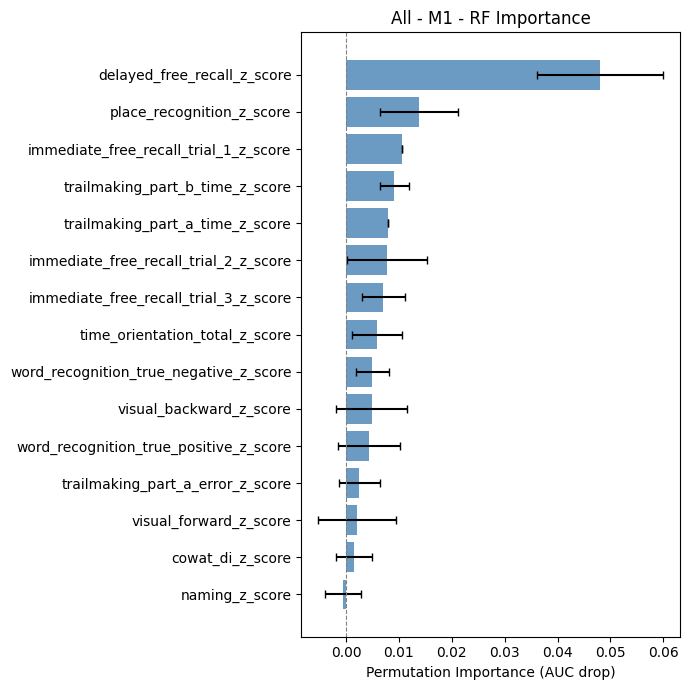


--- All/M2 [RF] 성능 ---
   fold        f1       auc
0     1  0.651852  0.779743
1     2  0.656489  0.762448
2     3  0.651515  0.742988
3     4  0.676471  0.802740
4     5  0.731343  0.807011

--- All/M2 [RF] 개별 Permutation Importance ---


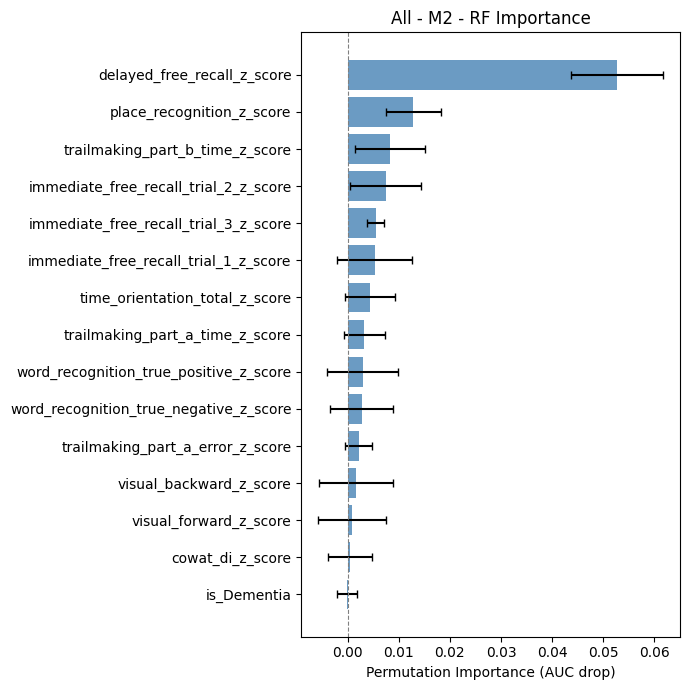


--- All/M2 [RF] Grouped Importance ---


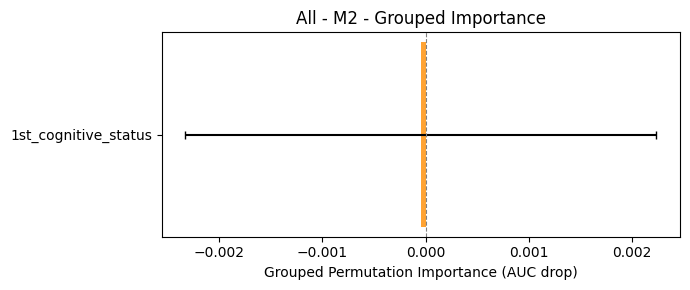


--- All/M3 [RF] 성능 ---
   fold        f1       auc
0     1  0.656934  0.775812
1     2  0.620155  0.775092
2     3  0.656489  0.749967
3     4  0.661871  0.798174
4     5  0.691176  0.812897

--- All/M3 [RF] 개별 Permutation Importance ---


/work/Project/amyloid_beta_diagnosis/pipeline.py:262: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/work/Project/amyloid_beta_diagnosis/pipeline.py:262: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


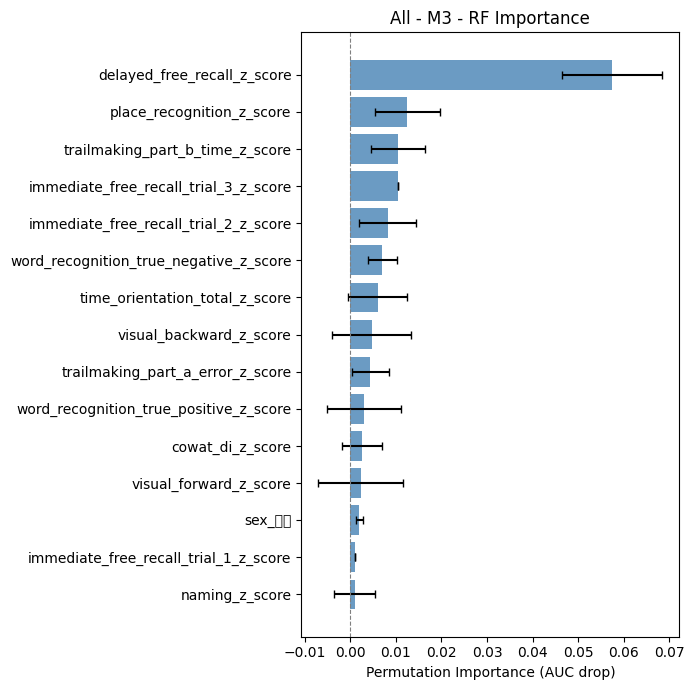


--- All/M3 [RF] Grouped Importance ---


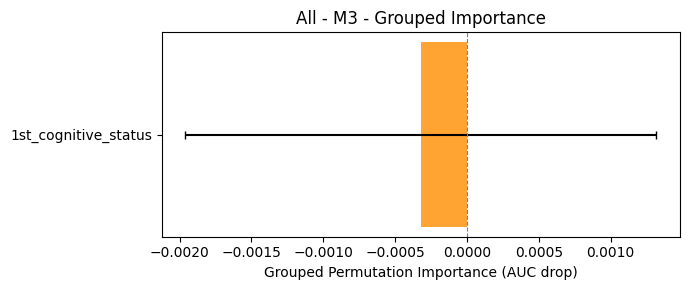


--- All/M4 [RF] 성능 ---
   fold        f1       auc
0     1  0.661765  0.760875
1     2  0.620155  0.775092
2     3  0.641221  0.753816
3     4  0.661871  0.801435
4     5  0.676692  0.814418

--- All/M4 [RF] 개별 Permutation Importance ---


/work/Project/amyloid_beta_diagnosis/pipeline.py:262: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/work/Project/amyloid_beta_diagnosis/pipeline.py:262: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


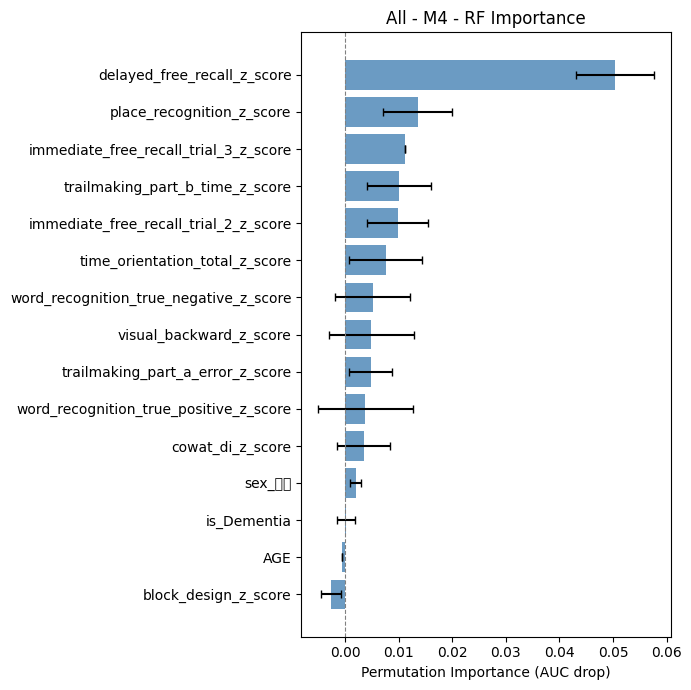


--- All/M4 [RF] Grouped Importance ---


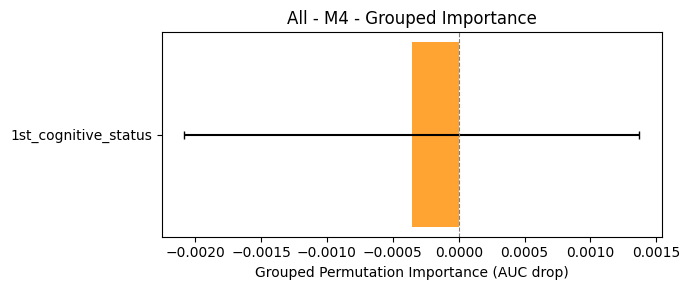


--- All/M5 [RF] 성능 ---
   fold        f1       auc
0     1  0.661765  0.773585
1     2  0.600000  0.753145
2     3  0.641221  0.753816
3     4  0.666667  0.799804
4     5  0.676692  0.814418

--- All/M5 [RF] 개별 Permutation Importance ---


/work/Project/amyloid_beta_diagnosis/pipeline.py:262: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/work/Project/amyloid_beta_diagnosis/pipeline.py:262: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


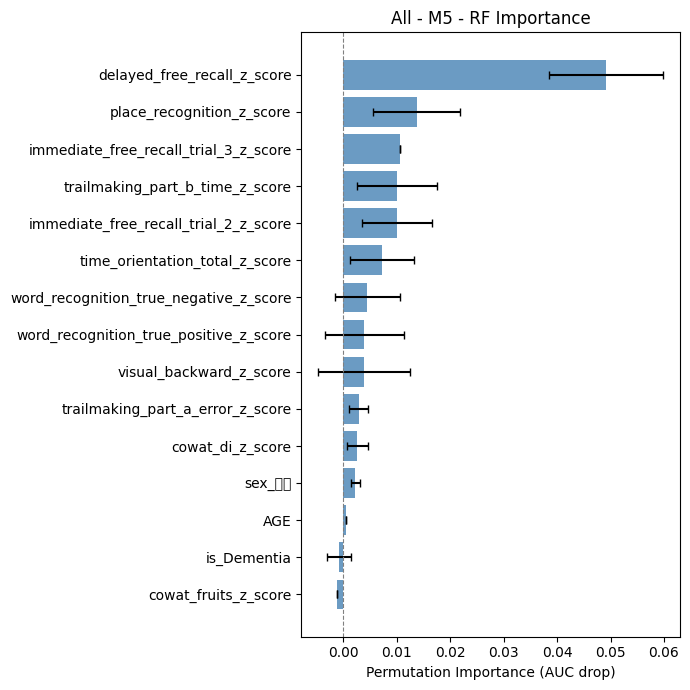


--- All/M5 [RF] Grouped Importance ---


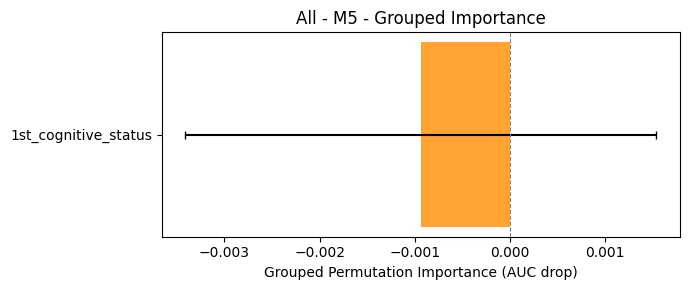


--- All/M6 [RF] 성능 ---
   fold        f1       auc
0     1  0.707692  0.815121
1     2  0.634146  0.818724
2     3  0.676923  0.778474
3     4  0.705882  0.809785
4     5  0.697674  0.826984

--- All/M6 [RF] 개별 Permutation Importance ---


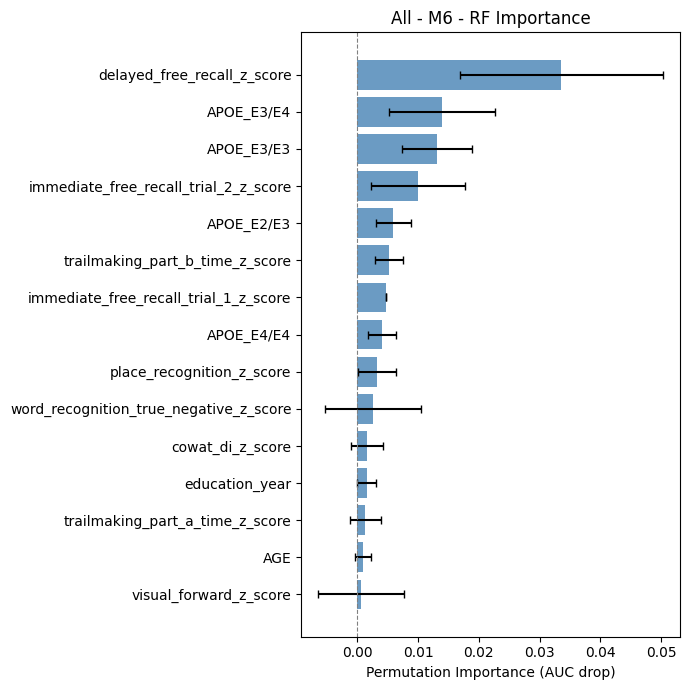


--- All/M6 [RF] Grouped Importance ---


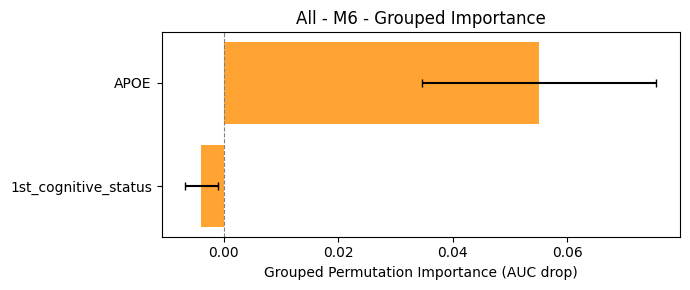


######################################################################
# Group: SCD
######################################################################

[SCD] model_type = LR

--- SCD/M1_SCD [LR] 성능 ---
   fold   f1       auc
0     1  0.0  0.500000
1     2  0.0  0.496032
2     3  0.0  0.380952
3     4  0.0  0.345238
4     5  0.0  0.297959

--- SCD/M1_SCD [LR] 개별 OR table (Wald test) ---
                                   feature  selected_folds_by_lasso   OR_mean  \
0                     block_design_z_score                        5  0.914001   
1                         cowat_di_z_score                        5  1.045428   
2                     cowat_fruits_z_score                        5  0.871825   
3              delayed_free_recall_z_score                        5  0.645914   
4    immediate_free_recall_trial_1_z_score                        5  1.356405   
5    immediate_free_recall_trial_2_z_score                        5  0.842748   
6    immediate_free_recall_trial_3_z_sc

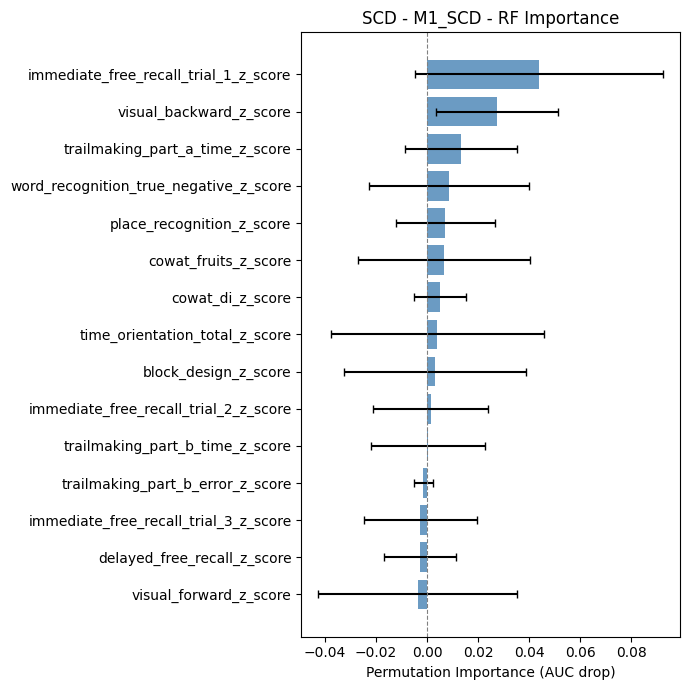


--- SCD/M2_SCD [RF] 성능 ---
   fold   f1       auc
0     1  0.0  0.613095
1     2  0.0  0.492063
2     3  0.0  0.466270
3     4  0.0  0.511905
4     5  0.0  0.542857

--- SCD/M2_SCD [RF] 개별 Permutation Importance ---


/work/Project/amyloid_beta_diagnosis/pipeline.py:262: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/work/Project/amyloid_beta_diagnosis/pipeline.py:262: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


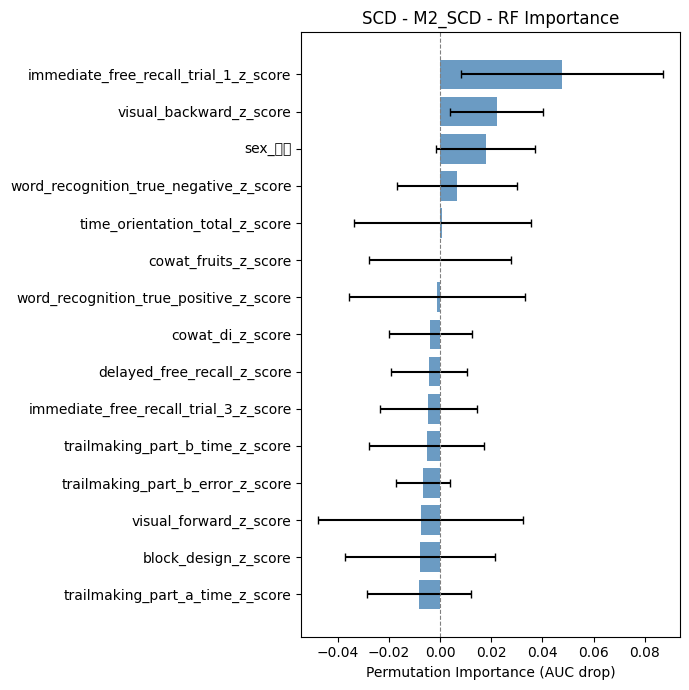


--- SCD/M3_SCD [RF] 성능 ---
   fold   f1       auc
0     1  0.0  0.670635
1     2  0.0  0.577381
2     3  0.0  0.450397
3     4  0.0  0.484127
4     5  0.0  0.579592

--- SCD/M3_SCD [RF] 개별 Permutation Importance ---


/work/Project/amyloid_beta_diagnosis/pipeline.py:262: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/work/Project/amyloid_beta_diagnosis/pipeline.py:262: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


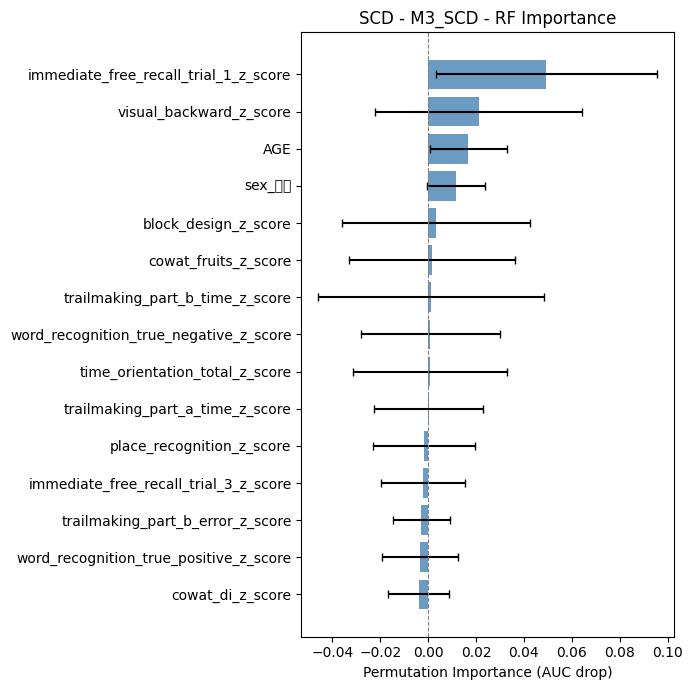


--- SCD/M4_SCD [RF] 성능 ---
   fold   f1       auc
0     1  0.0  0.682540
1     2  0.0  0.531746
2     3  0.0  0.404762
3     4  0.0  0.480159
4     5  0.0  0.508163

--- SCD/M4_SCD [RF] 개별 Permutation Importance ---


/work/Project/amyloid_beta_diagnosis/pipeline.py:262: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/work/Project/amyloid_beta_diagnosis/pipeline.py:262: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


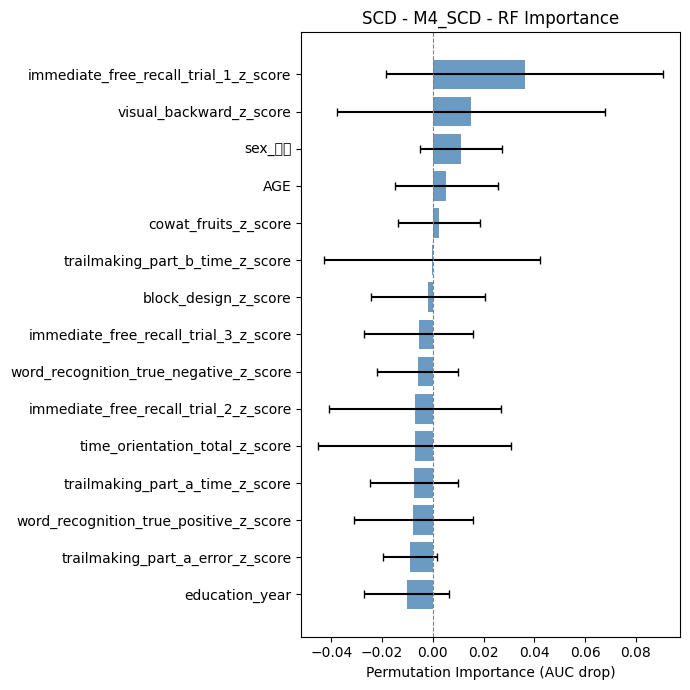


--- SCD/M5_SCD [RF] 성능 ---
   fold   f1       auc
0     1  0.0  0.674603
1     2  0.0  0.476190
2     3  0.0  0.462302
3     4  0.0  0.436508
4     5  0.0  0.593878

--- SCD/M5_SCD [RF] 개별 Permutation Importance ---


/work/Project/amyloid_beta_diagnosis/pipeline.py:262: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/work/Project/amyloid_beta_diagnosis/pipeline.py:262: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


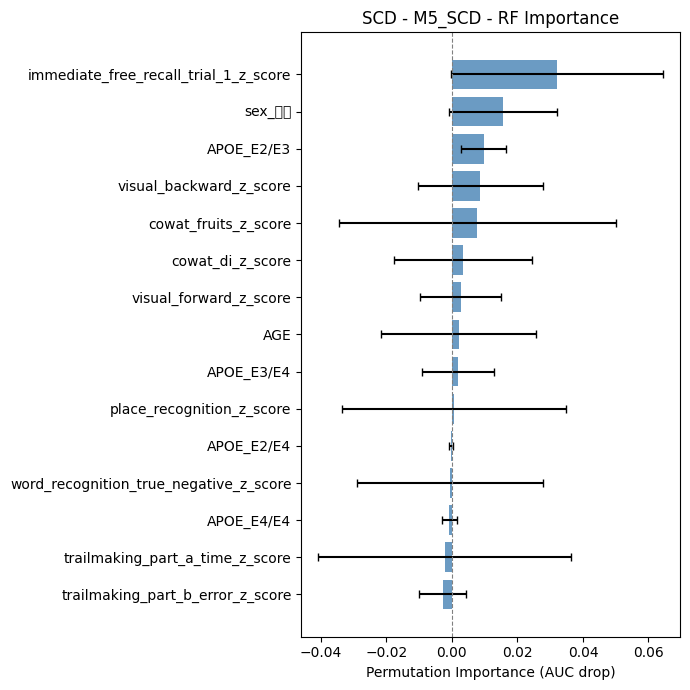


--- SCD/M5_SCD [RF] Grouped Importance ---


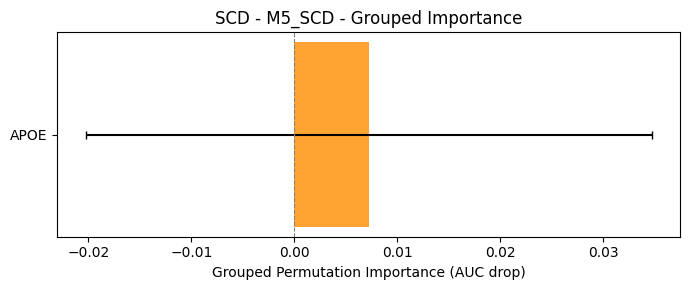


######################################################################
# Group: MCI
######################################################################

[MCI] model_type = LR

--- MCI/M1_MCI [LR] 성능 ---
   fold        f1       auc
0     1  0.423077  0.636456
1     2  0.355556  0.670424
2     3  0.458333  0.739390
3     4  0.509804  0.627060
4     5  0.510638  0.710852

--- MCI/M1_MCI [LR] 개별 OR table (Wald test) ---
                                   feature  selected_folds_by_lasso   OR_mean  \
0              delayed_free_recall_z_score                        5  0.551992   
1    immediate_free_recall_trial_2_z_score                        4  0.704143   
2                         cowat_di_z_score                        3  1.332771   
3                     block_design_z_score                        3  0.936608   
4                     cowat_fruits_z_score                        3  1.394776   
5    immediate_free_recall_trial_1_z_score                        3  0.919662   
6    imme

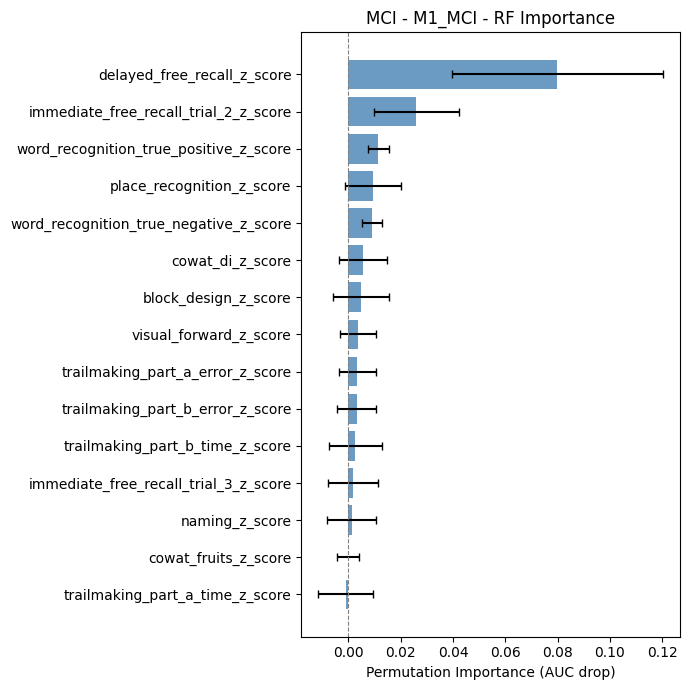


--- MCI/M2_MCI [RF] 성능 ---
   fold        f1       auc
0     1  0.444444  0.571429
1     2  0.428571  0.713528
2     3  0.545455  0.759284
3     4  0.474576  0.620536
4     5  0.487805  0.663805

--- MCI/M2_MCI [RF] 개별 Permutation Importance ---


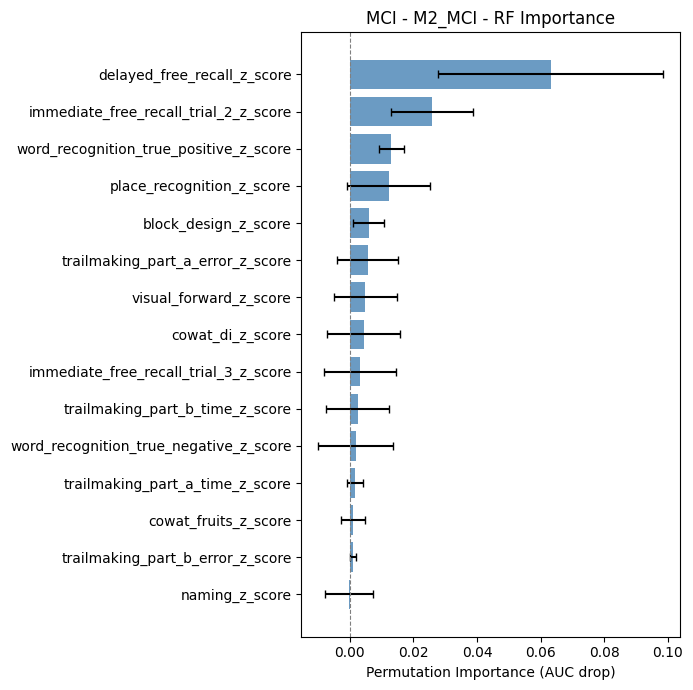


--- MCI/M3_MCI [RF] 성능 ---
   fold        f1       auc
0     1  0.444444  0.571429
1     2  0.390244  0.719164
2     3  0.577778  0.750332
3     4  0.474576  0.620536
4     5  0.523810  0.663805

--- MCI/M3_MCI [RF] 개별 Permutation Importance ---


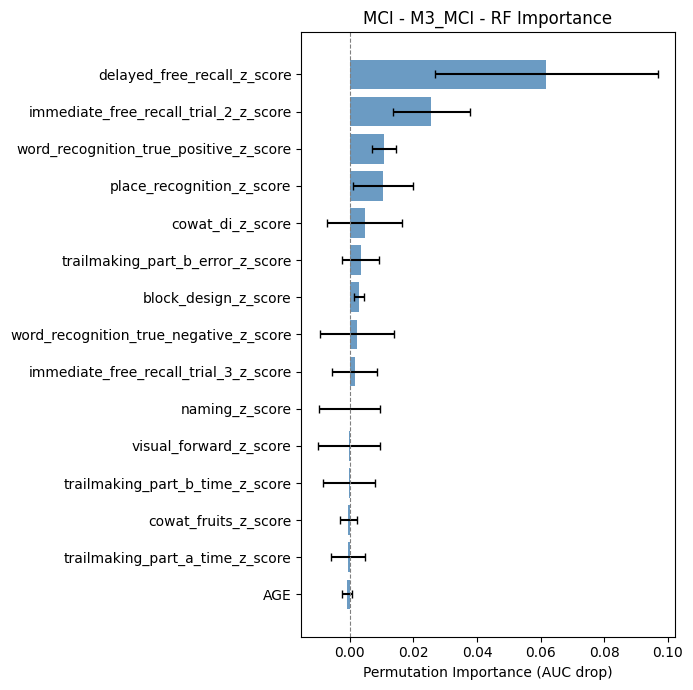


--- MCI/M4_MCI [RF] 성능 ---
   fold        f1       auc
0     1  0.490566  0.624326
1     2  0.341463  0.713528
2     3  0.590909  0.766578
3     4  0.474576  0.620536
4     5  0.536585  0.681662

--- MCI/M4_MCI [RF] 개별 Permutation Importance ---


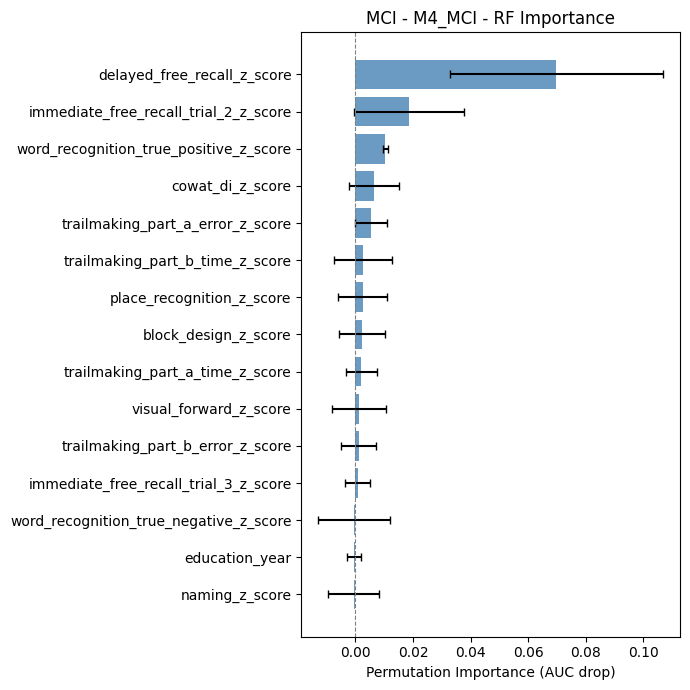


--- MCI/M5_MCI [RF] 성능 ---
   fold        f1       auc
0     1  0.481481  0.643868
1     2  0.488889  0.751658
2     3  0.604651  0.790119
3     4  0.448980  0.640797
4     5  0.523810  0.719093

--- MCI/M5_MCI [RF] 개별 Permutation Importance ---


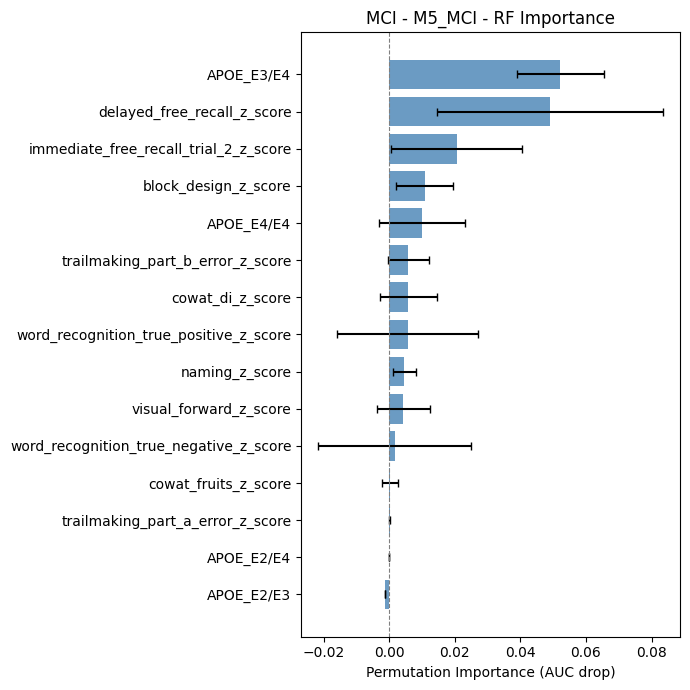


--- MCI/M5_MCI [RF] Grouped Importance ---


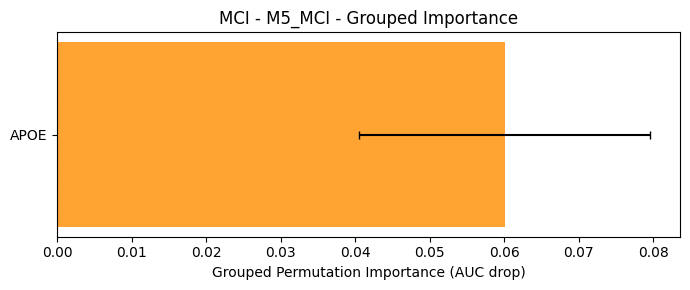


######################################################################
# Group: Dementia
######################################################################

[Dementia] model_type = LR

--- Dementia/M1_Dementia [LR] 성능 ---
   fold        f1       auc
0     1  0.871795  0.882883
1     2  0.750000  0.657658
2     3  0.850000  0.767886
3     4  0.743590  0.651828
4     5  0.805195  0.707472

--- Dementia/M1_Dementia [LR] 개별 OR table (Wald test) ---
                                   feature  selected_folds_by_lasso   OR_mean  \
0                     block_design_z_score                        5  0.747089   
1                         cowat_di_z_score                        5  1.784963   
2                     cowat_fruits_z_score                        5  1.287798   
3              delayed_free_recall_z_score                        5  0.675175   
4                           naming_z_score                        5  1.532959   
5    immediate_free_recall_trial_3_z_score                  

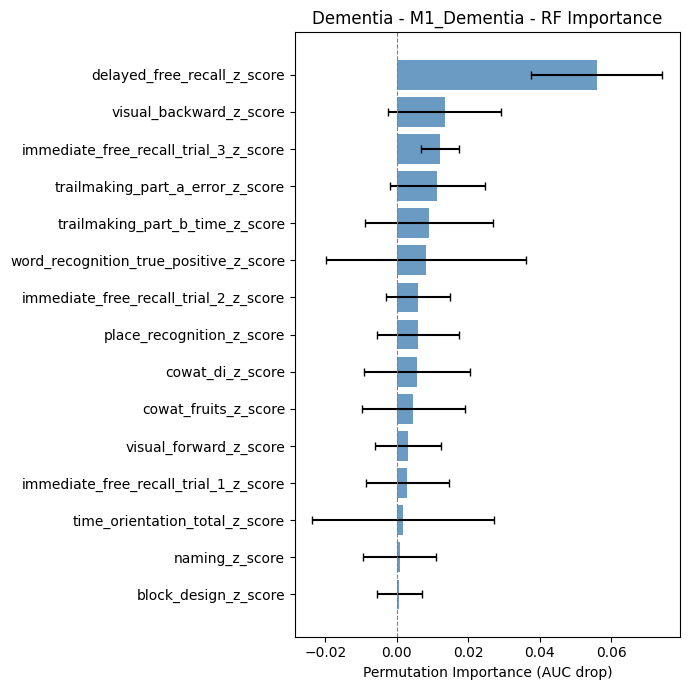


--- Dementia/M2_Dementia [RF] 성능 ---
   fold        f1       auc
0     1  0.823529  0.856607
1     2  0.790698  0.622372
2     3  0.843373  0.718601
3     4  0.761905  0.605723
4     5  0.765432  0.670906

--- Dementia/M2_Dementia [RF] 개별 Permutation Importance ---


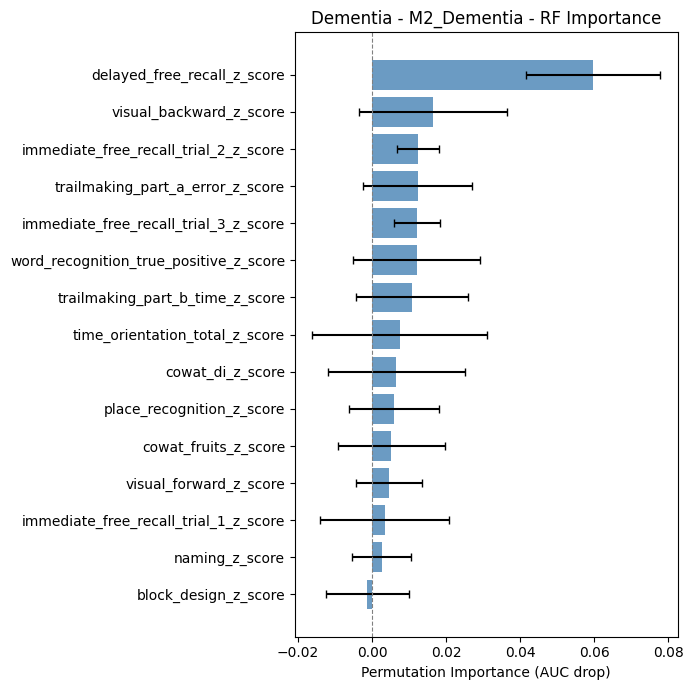


--- Dementia/M3_Dementia [RF] 성능 ---
   fold        f1       auc
0     1  0.823529  0.869369
1     2  0.776471  0.568318
2     3  0.833333  0.729730
3     4  0.776471  0.593800
4     5  0.790123  0.664547

--- Dementia/M3_Dementia [RF] 개별 Permutation Importance ---


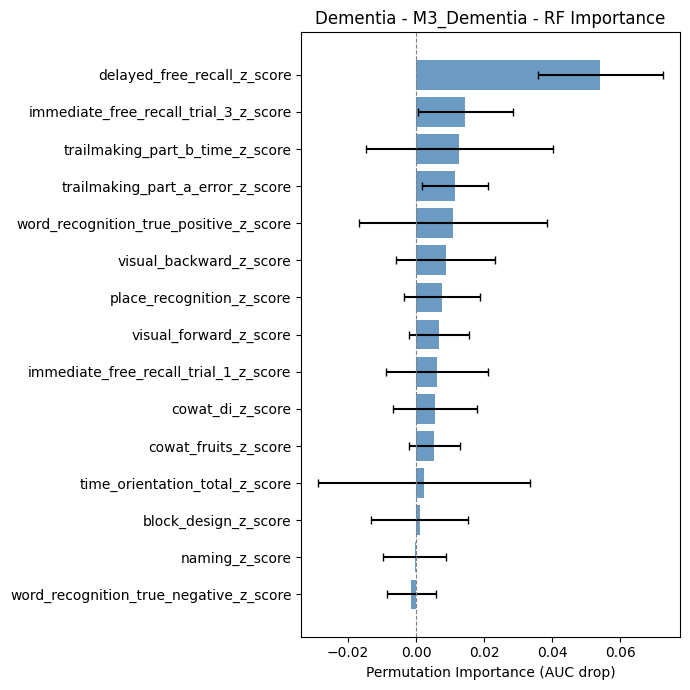


--- Dementia/M4_Dementia [RF] 성능 ---
   fold        f1       auc
0     1  0.833333  0.856607
1     2  0.795181  0.578829
2     3  0.833333  0.729730
3     4  0.772727  0.570747
4     5  0.790123  0.664547

--- Dementia/M4_Dementia [RF] 개별 Permutation Importance ---


/work/Project/amyloid_beta_diagnosis/pipeline.py:262: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/work/Project/amyloid_beta_diagnosis/pipeline.py:262: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


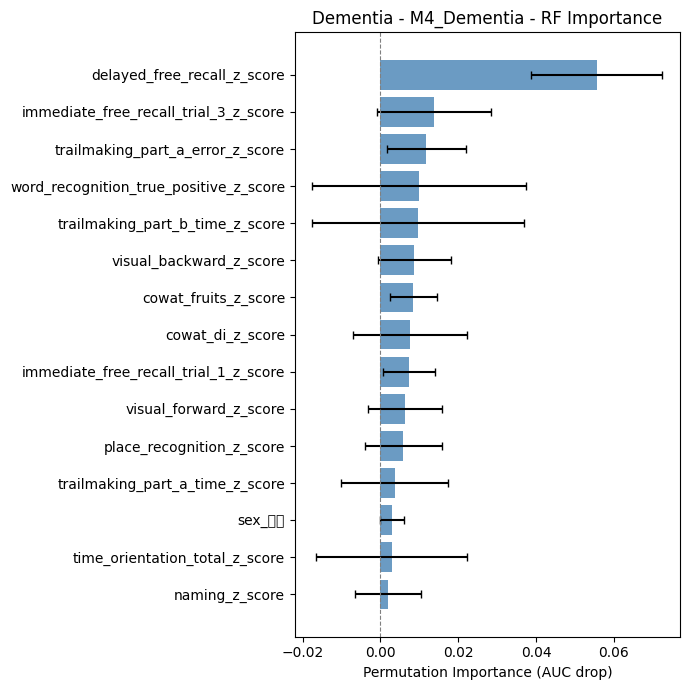


--- Dementia/M5_Dementia [RF] 성능 ---
   fold        f1       auc
0     1  0.835443  0.881381
1     2  0.814815  0.710961
2     3  0.850000  0.791733
3     4  0.784810  0.701113
4     5  0.825000  0.802862

--- Dementia/M5_Dementia [RF] 개별 Permutation Importance ---


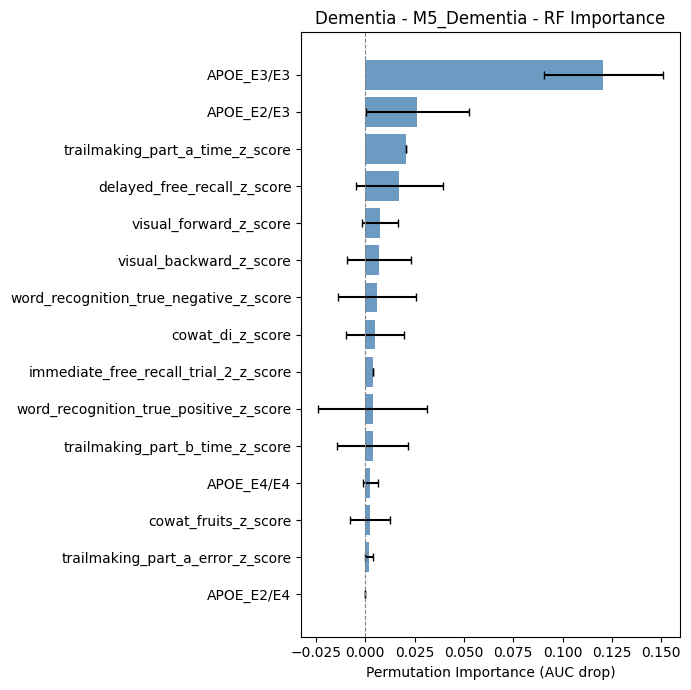


--- Dementia/M5_Dementia [RF] Grouped Importance ---


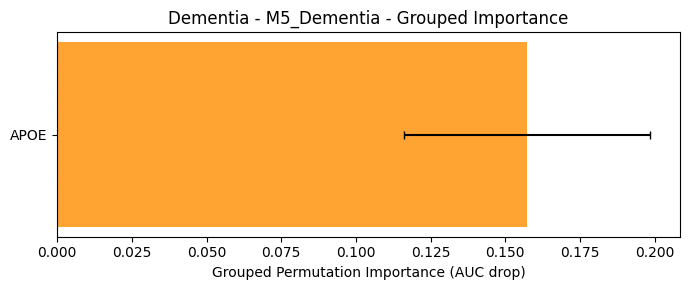

In [13]:
print_full_report(detail_results)